In [24]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

load_dotenv()

True

In [25]:
# model
model = ChatOpenAI(model="gpt-4.1-mini")
# parser
parser = StrOutputParser()

In [26]:
# define state
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str
    rating: int

In [27]:
class Rating(BaseModel):
    rating: int = Field(
        ge = 0,
        le = 10,
        description="Rating between 0 to 10"
    )

In [28]:
structured_model = model.with_structured_output(Rating)

In [29]:
def generate_outline(state: BlogState) -> BlogState:
    topic = state['topic']
    
    prompt = PromptTemplate(
        template="""
        Create a outline on {topic} for a blog.
        """,
        input_variables=['topic']
    )
    
    chain = prompt | model | parser
    res = chain.invoke({"topic":topic})
    
    state['outline'] = res
    
    return state

In [30]:
def generate_blog(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outline']
    
    prompt = PromptTemplate(
        template="""
        Write a blog on the {topic} should follow {outline} outline.
        """,
        input_variables=['topic', 'outline']
    )
    
    chain = prompt | model | parser
    res = chain.invoke({"topic":topic, "outline":outline})
    
    state['blog'] = res

    return state

In [39]:
def rate_blog(state: BlogState):
    
    outline = state['outline']
    blog = state['blog']
    
    prompt = PromptTemplate(
        template="""
        On the basis of outline and blog rate the blog out of 10 only return a number. \n outline -> {outline}, blog = {blog}
        """,
        input_variables = ['outline', 'blog']
    )
    
    chain = prompt | structured_model
    
    res = chain.invoke({"outline": outline, "blog": blog})
    
    # state['rating'] = res
    
    return {
        'rating': res.rating
    }

In [40]:
# define a graph
graph = StateGraph(BlogState)

# add nodes
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)
graph.add_node('rate_blog', rate_blog)

# add edges to your graph
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', 'rate_blog')
graph.add_edge('rate_blog', END)

# compile the graph
workflow = graph.compile()

In [41]:
# execute the graph
initial_state = {"topic":"solar system"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'solar system', 'outline': 'Sure! Here’s a detailed outline for a blog about the solar system:\n\n---\n\n**Outline: Exploring the Solar System**\n\n1. **Introduction**  \n   - Brief overview of the solar system  \n   - Importance of studying the solar system  \n   - What readers can expect from the blog  \n\n2. **What is the Solar System?**  \n   - Definition and components  \n   - Formation and age of the solar system  \n   - The Sun as the central star  \n\n3. **The Sun**  \n   - Characteristics (size, composition, temperature)  \n   - Role in the solar system (gravity, energy source)  \n   - Interesting facts  \n\n4. **The Planets**  \n   - Overview: Dividing planets into terrestrial and gas giants  \n   - **Inner Planets (Terrestrial):**  \n     - Mercury: Closest to the Sun, surface features, temperature extremes  \n     - Venus: Atmosphere, greenhouse effect, surface conditions  \n     - Earth: Our home, atmosphere, water presence  \n     - Mars: The Red Planet, explora

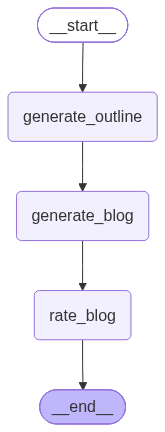

In [42]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [43]:
print(final_state['rating'])

9
